In [1]:
import os
import sys
repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

import numpy as np
import matplotlib.pyplot as plt
from utils import load_yaml
from data_generation.differential_equations import PoissonSetup1LeastSquares

----------------------------------------
2025-11-06 15:15:54 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)

In [3]:
eigenvalues = np.load(os.path.join(train_dataset_path, "hdiv_h1_pod_eigvals.npy"))

In [4]:
eigenvalues.shape

(500,)

In [5]:
num_basis_list = [1, 2, 4, 8, 16, 32, 64, 128]

In [6]:
error_estimate_list = []
relative_error_estimate_list = []
for i, rank in enumerate(num_basis_list):
    trailing_eigenvalues = eigenvalues[rank+1-1:] 
    sum_squared_trailing_eigenvalues = np.sum(trailing_eigenvalues**2)
    error_estimate_list.append(np.sqrt(sum_squared_trailing_eigenvalues))
    relative_error_estimate_list.append(np.sqrt(sum_squared_trailing_eigenvalues)/np.sqrt(np.sum(eigenvalues**2)))
error_estimate_list = np.array(error_estimate_list)
relative_error_estimate_list = np.array(relative_error_estimate_list)

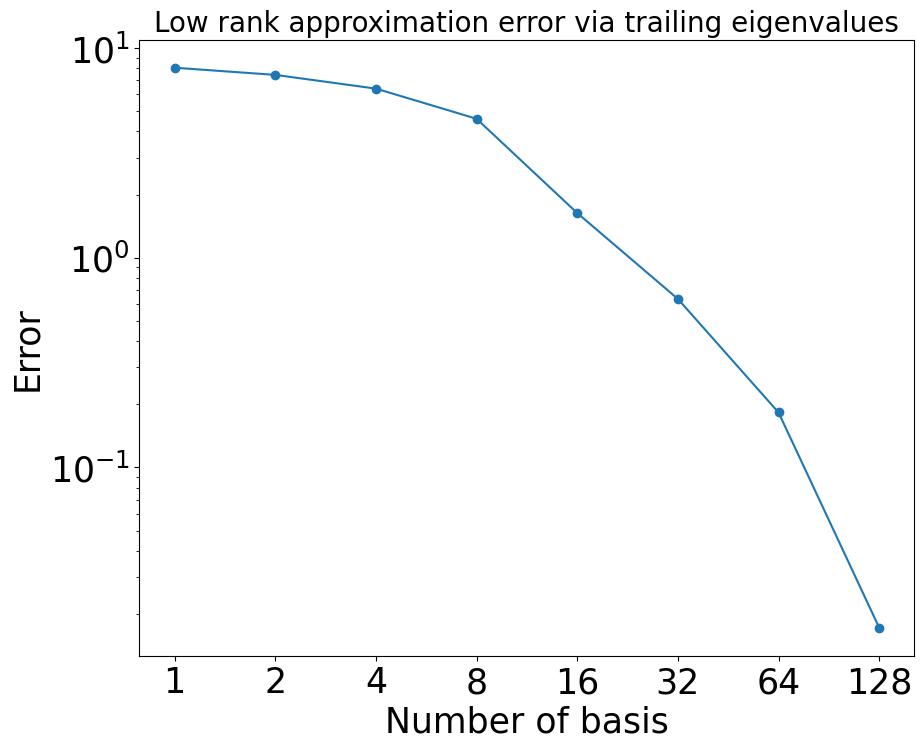

In [7]:
plt.figure(figsize=(10, 8))
plt.plot(num_basis_list, error_estimate_list, marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)
# Set x and y ticks font size
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

plt.xlabel('Number of basis', fontsize=25)
plt.ylabel('Error', fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.title('Low rank approximation error via trailing eigenvalues', fontsize=20)
plt.savefig("analysis_low_rank_approximation_error_via_trailing_eigenvalue_estimate.png", dpi=300, bbox_inches='tight')
plt.show()

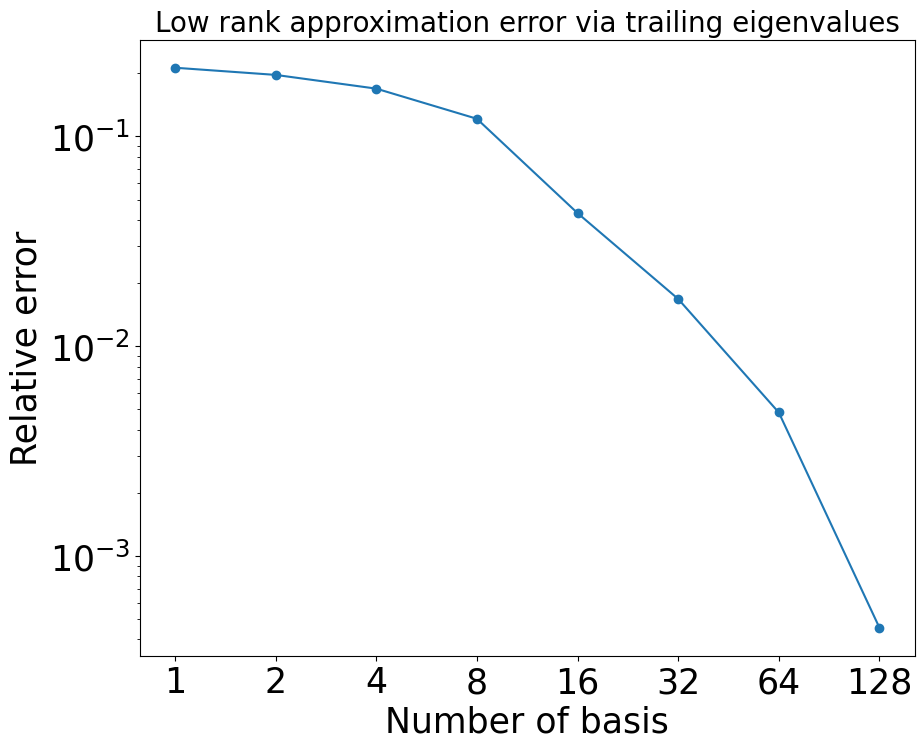

In [8]:
plt.figure(figsize=(10, 8))
plt.plot(num_basis_list, relative_error_estimate_list, marker='o')
plt.xscale('log', base=2)
plt.yscale('log', base=10)

# Set x and y ticks font size
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

plt.xlabel('Number of basis', fontsize=25)
plt.ylabel('Relative error', fontsize=25)
plt.tick_params(axis='both', which='major', labelsize=25)
plt.title('Low rank approximation error via trailing eigenvalues', fontsize=20)
plt.savefig("analysis_low_rank_approximation_relative_error_via_trailing_eigenvalue_estimate.png", dpi=300, bbox_inches='tight')
plt.show()  